In [ ]:
#นายธนกฤต ชูจิต sec2 รหัส116710400148-8
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import LabelEncoder

In [ ]:
#นายธนกฤต ชูจิต sec2 รหัส116710400148-8
#Lab1
# Load Dataset
df = pd.read_csv('student_dataset_v3.csv')

print("1. Display Shape:", df.shape)

print("\n2. Display Data Types:")
print(df.dtypes)

print("\n3. Display Summary Statistics:")
print(df.describe(include='all'))

print("\n4. Display Missing Values:")
print(df.isnull().sum())

print("\n5. Display Duplicate Records:", df.duplicated().sum())

print("\n6. Display Class Distribution:")
print(df['Passed'].value_counts())

1. Display Shape: (21, 7)

2. Display Data Types:
Student_ID         str
Gender             str
Age            float64
Major              str
Study_Hours    float64
Exam_Score     float64
Passed             str
dtype: object

3. Display Summary Statistics:
       Student_ID Gender        Age     Major  Study_Hours  Exam_Score Passed
count          21     21  20.000000        21       20.000   20.000000     21
unique         20      5        NaN         3          NaN         NaN      2
top       STU1000      F        NaN  Computer          NaN         NaN    Yes
freq            2     10        NaN        14          NaN         NaN     13
mean          NaN    NaN  23.700000       NaN       11.655   58.700000    NaN
std           NaN    NaN  17.770763       NaN        5.991   16.638889    NaN
min           NaN    NaN  18.000000       NaN        3.900   38.000000    NaN
25%           NaN    NaN  19.000000       NaN        6.600   45.500000    NaN
50%           NaN    NaN  20.000000      

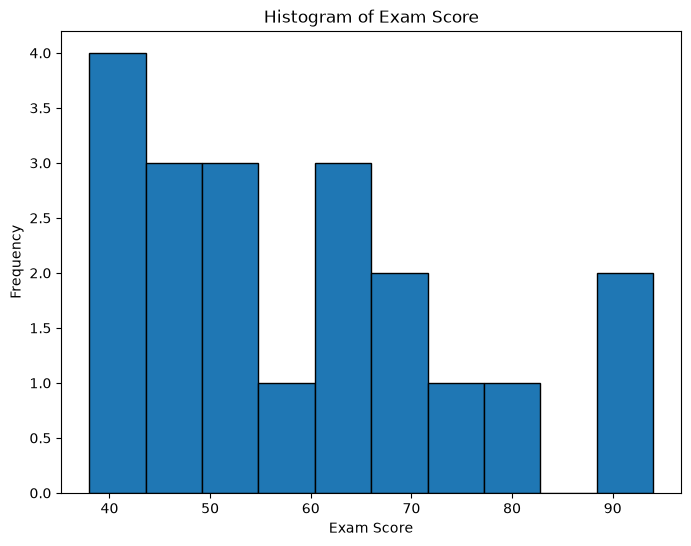

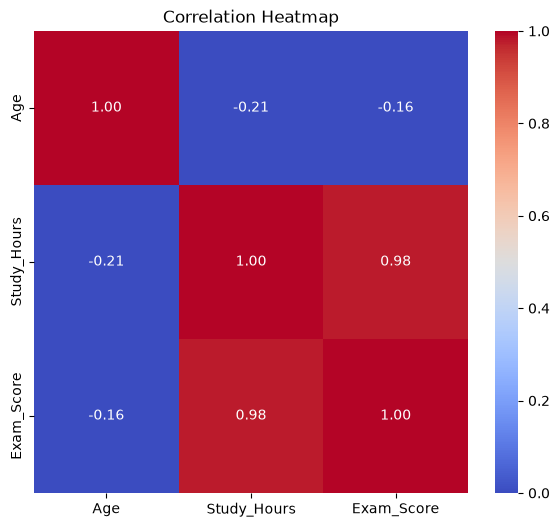

In [ ]:
#นายธนกฤต ชูจิต sec2 รหัส116710400148-8
#Lab2
# ต้องทำ Type Conversion เล็กน้อยก่อนพลอต เพื่อป้องกัน Error จากไฟล์ดิบ
df_viz = df.copy()
df_viz['Study_Hours'] = pd.to_numeric(df_viz['Study_Hours'], errors='coerce')

# 1. Histogram of Exam Score
plt.figure(figsize=(8, 6))
plt.hist(df_viz['Exam_Score'].dropna(), bins=10, edgecolor='black', color='#1f77b4')
plt.title('Histogram of Exam Score')
plt.xlabel('Exam Score')
plt.ylabel('Frequency')
plt.show()

# 2. Correlation Heatmap
plt.figure(figsize=(7, 6))
# เลือกเฉพาะคอลัมน์ตัวเลข Age, Study_Hours, Exam_Score
numeric_cols = df_viz[['Age', 'Study_Hours', 'Exam_Score']]
sns.heatmap(numeric_cols.corr(), annot=True, cmap='coolwarm', fmt=".2f", vmin=0, vmax=1)
plt.title('Correlation Heatmap')
plt.show()

In [ ]:
#นายธนกฤต ชูจิต sec2 รหัส116710400148-8
#lab3
df_clean = df.copy()

# 1. Data Type Conversion (แก้ Study_Hours จากข้อความให้เป็นตัวเลข)
df_clean['Study_Hours'] = pd.to_numeric(df_clean['Study_Hours'], errors='coerce')

# 2. Incorrect Data Correction (แก้เพศที่พิมพ์สลับไปมา และอายุที่ผิดปกติ)
df_clean['Gender'] = df_clean['Gender'].replace({'female': 'Female', 'F': 'Female', 'M': 'Male'})
df_clean.loc[(df_clean['Age'] <= 0) | (df_clean['Age'] > 60), 'Age'] = np.nan

# 3. Duplicate Removal (ลบข้อมูลที่ซ้ำกัน)
df_clean = df_clean.drop_duplicates().reset_index(drop=True)

# 4. Compare Mean / Median ของคะแนนสอบ
mean_score = df_clean['Exam_Score'].mean()
median_score = df_clean['Exam_Score'].median()
print(f"Mean of Exam Score: {mean_score:.2f}")
print(f"Median of Exam Score: {median_score:.2f}")

# 5. Missing Value Handling (เติมค่าว่างด้วยค่ามัธยฐาน)
df_clean['Age'] = df_clean['Age'].fillna(df_clean['Age'].median())
df_clean['Study_Hours'] = df_clean['Study_Hours'].fillna(df_clean['Study_Hours'].median())
df_clean['Exam_Score'] = df_clean['Exam_Score'].fillna(df_clean['Exam_Score'].median())

print("\nตรวจสอบค่าว่างอีกครั้งหลังจากทำความสะอาด:")
print(df_clean.isnull().sum())

Mean of Exam Score: 59.79
Median of Exam Score: 58.00

ตรวจสอบค่าว่างอีกครั้งหลังจากทำความสะอาด:
Student_ID     0
Gender         0
Age            0
Major          0
Study_Hours    0
Exam_Score     0
Passed         0
dtype: int64


In [ ]:
#นายธนกฤต ชูจิต sec2 รหัส116710400148-8
#lab4
# 1. Label Encoding สำหรับคอลัมน์ Passed (เปลี่ยน Yes/No เป็น 1/0)
le = LabelEncoder()
df_clean['Passed_Encoded'] = le.fit_transform(df_clean['Passed'])

# 2. One-Hot Encoding สำหรับคอลัมน์ Major และ Gender (สร้างคอลัมน์ดัมมี่ 0/1)
df_final = pd.get_dummies(df_clean, columns=['Major', 'Gender'], drop_first=True)

print("--- ตัวอย่างข้อมูลหลังทำ Data Preprocessing เสร็จสิ้น ---")
display(df_final.head())

--- ตัวอย่างข้อมูลหลังทำ Data Preprocessing เสร็จสิ้น ---


,Student_ID,Age,Study_Hours,Exam_Score,Passed,Passed_Encoded,Major_Computer,Major_Electrical,Gender_Male
0,STU1000,20.0,3.9,38.0,No,0,True,False,False
1,STU1001,21.0,4.2,41.0,No,0,False,True,False
2,STU1002,19.5,5.8,42.0,No,0,True,False,False
3,STU1003,18.0,7.9,44.0,No,0,True,False,False
4,STU1004,20.0,6.0,46.0,No,0,False,True,True
